# Analysis of Marathon Results #

$Author$: Michael Simons

$Student ID$: 50317142

$Class$: MTH 448

$Date$: 05/9/23

## Introduction ##

Kernel density estimation (KDE) is a technique used in computing an approximate probability density function of one or more random variables. It is a powerful procedure often utilized in modeling the underlying distribution of data. Linear regression is another statistical technique, which is used to model a relation between variables by fitting a linear equation to the observed data. In this report, we will apply a combination of KDE and Bayesian modeling, as well as linear regression techniques to predict attributes of runners, and examine the accuracy of such predictions. Through this analysis, we hope to gain insights into the performance patterns of marathon runners and provide a framework for using statistical techniques to make predictions in other domains.

The marathon_results dataset is a csv file containing data corresponding to over 26,000 runners of a marathon. The data consists of 17 columns including age, gender, country, and various times at different points throughout the marathon, such as the 5K, 10K, and 40K marks, as well as the finish time. The relation between performance and other factors such as age and gender will be useful in applying kernel density estimation and linear regression to make predictions of a runner's attributes given their performance. In addition, the accuracy of the predictions made using KDE and linear regression will be compared to the accuracy of those made using a k-NN classification approach. This comparison will uncover strengths, and weaknesses, and trade-offs between each method and their performance in different types of problems.

## Data Preparation ##
Firstly, the data will be extracted from the file titled `marathon_results.csv` and stored into a Pandas dataframe. This will allow us to examine the contents and structure of the dataset.

In [1]:
import pandas as pd

#Extract the marathon results into a data frame
with open ('marathon_results.csv','r') as csvfile:
    marathon_results=pd.read_csv(csvfile)

#Sample three random entries to observe formatting
marathon_results.sample(3)

,Age,M/F,Country,5K,10K,15K,20K,Half,25K,30K,35K,40K,Finish,Pace,Overall,Gender,Division
1260,32,M,USA,00:20:11,00:40:04,00:59:53,01:19:56,01:24:19,01:39:53,02:00:04,02:20:49,02:42:45,02:53:01,00:06:36,1263,1206,986
4135,30,M,USA,00:21:07,00:42:18,01:03:22,01:24:26,01:29:00,01:45:28,02:07:03,02:29:18,02:55:00,03:07:45,00:07:10,4145,3827,2592
16004,40,F,USA,00:27:25,00:53:55,01:20:06,01:47:49,01:53:35,02:14:33,02:42:12,03:10:19,03:37:36,03:49:07,00:08:45,16103,5917,1078


Observably and and as previously mentioned, the data includes several attributes of each runner. This includes age, gender, country, and various timestamps at different points in the marathon.

In order to compare the performance of runners, each runner's finish time can be converted to a singlular number representing the amount of minutes taken to complete the marathon. This will be done by converting the datetime expression to an amount of seconds and dividing by 60.

In [2]:
#Add a new column to the data frame containing the total amount of minutes it took the runner to finish the marathon
marathon_results['total_minutes']=pd.to_timedelta(marathon_results['Finish']).dt.total_seconds()/60

## One-Dimensional KDE Bayesian Model ## 

In order to analyze the distribution of finish times between male and female runners, a one-dimensional kernel density estimation will applied to the marathon results data set. The previously stored data frame will be split based on gender, and fit each gender's total minutes column will be fit into a KDE using scipy's gaussian_kde function.

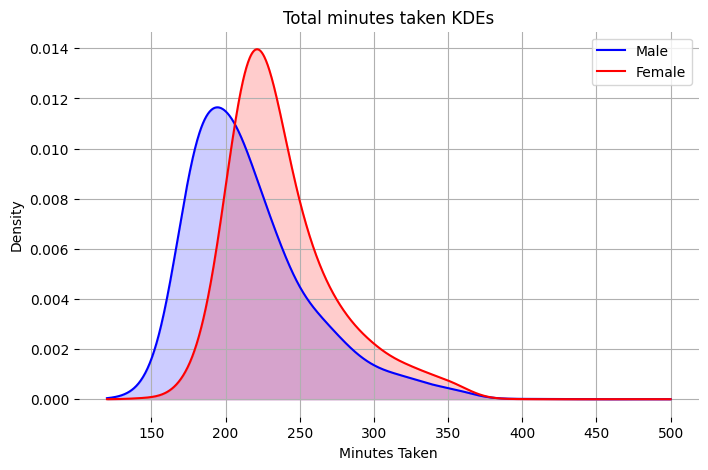

In [3]:
from  scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

#Split marathon results into a data frame for each gender
male_runners=marathon_results[marathon_results['M/F']=='M']
female_runners=marathon_results[marathon_results['M/F']=='F']

#Fit each gender's total_minutes column into a KDE 
male_kde=gaussian_kde(male_runners['total_minutes'], bw_method=0.3)
female_kde=gaussian_kde(female_runners['total_minutes'], bw_method=0.3)

#Initialize subplot to display KDEs
plt.figure(figsize=(8,5))
plt.title('Total minutes taken KDEs')
plt.xlabel('Minutes Taken')
plt.ylabel('Density')
plt.grid(True)
x = np.linspace(120,500,1000)#X-axis points
plt.plot(x, male_kde(x),label='Male', color='blue')
plt.fill_between(x, male_kde(x), alpha=0.2, color='blue')

plt.plot(x, female_kde(x),label='Female', color='red')
plt.fill_between(x, female_kde(x), alpha=0.2, color='red')

#Remove unecessary edges
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.legend()
plt.show()

The plot shows that the finish times for male runners tend to be faster than those for female runners. Another note of interest is that finish times for female runners have a tigher distribution.

The resulting KDEs will now be used to implement a Bayesian model which predicts the gender of a runner given the total minutes it took them to complete the marathon Evaluating this model will provide insight towards the accuracy which such one-dimensional models can classify gender based on performance data.

In [4]:
#Predict the gender of a runner given the amount of minutes taken to finish the marathon
def one_dimensional_predict(minutes_taken):
    male_component=male_kde.evaluate(minutes_taken)[0]             #Compute male component
    female_component=female_kde.evaluate(minutes_taken)[0]         #Compute female component
    products=np.log10(np.array([male_component,female_component])) #Use logarithm probabilities to avoid underflow
    return ['M','F'][products.argmax()] #Return gender with highest probability

To evaluate the model's accuracy, a gender prediction will be made for each entry of the marathon results data frame. The prediction will then be compared to the true gender, and an the percentage of correct predictions will provide the accuracy value.

In [5]:
correct=0       #Track correct predictions
incorrect=0     #Track incorrect predictions
for _,row in marathon_results.iterrows():                    #Iterate through data frame rows
    prediction=one_dimensional_predict(row['total_minutes']) #Make prediction
    if prediction==row['M/F']: #Compare prediction to true value
        correct+=1
    else:
        incorrect+=1
#Display the model's accuracy
print(f"Accuracy of 1-D KDE predictions: approx. {float(correct)/(float(correct)+float(incorrect))}") #Display final accuracy

Accuracy of 1-D KDE predictions: approx. 0.6509620503460339


## Two-Dimensional KDE Bayesian Model ##

In addition to the one-dimensional analysis, a two-dimensional KDE will be performed to explore the relationship between finish times, age, and gender. The total minutes taken and age columns of both the male and female data frames will be fit into KDEs. In fitting the data, it will be necessary to take the transpose of the columns as to meet the gaussian_kde function's expected input shape. Once the KDEs have been fit, a Bayesian model will be implemented to predict the gender of a runner given their total minutes taken to finish the marathon and their age.

In [6]:
import plotly.graph_objects as go

#Fit each gender's total_minutes column into a KDE 
male_kde=gaussian_kde(male_runners[['total_minutes','Age']].T, bw_method=0.3)
female_kde=gaussian_kde(female_runners[['total_minutes','Age']].T, bw_method=0.3)


#Predict the gender of a runner given the amount of minutes taken to finish the marathon and their age
def two_dimensional_predict(minutes_taken,age):
    male_component=male_kde.evaluate([minutes_taken,age])[0]             #Compute male component
    female_component=female_kde.evaluate([minutes_taken,age])[0]         #Compute female component
    products=np.log10(np.array([male_component,female_component]))       #Use logarithm probabilities to avoid underflow
    return ['M','F'][products.argmax()] #Return gender with highest probability

Evaluating the accuracy of the predictions made using tis techniques model provide a better understanding of the effect of additional variables on prediction accuracy

In [7]:
correct=0       #Track correct predictions
incorrect=0     #Track incorrect predictions
for _,row in marathon_results.iterrows(): #Iterate through data frame rows
    prediction=two_dimensional_predict(row['total_minutes'],row['Age']) #Make prediction
    if prediction==row['M/F']: #Compare prediction to true value
        correct+=1
    else:
        incorrect+=1
print(f"Accuracy of 2-D KDE predictions: approx. {float(correct)/(float(correct)+float(incorrect))}") #Display final accuracy

Accuracy of 2-D KDE predictions: approx. 0.7633660354399574


The difference in accuracy compared to the one-dimensional model is very significant. This indicates that age is an important factor in accurately predicting a runner's gender. As expected, the results also suggest that the accuracy of such models will improve as additional variabcles are introduced.

## k-NN Classification Comparison ##

As previously mentioned, the k-nearest neighbor classification algorithm will also be applied to make predictions of each runner's gender. The prediction accuracy will then be compared to the previously computed accuracy of the one-dimensional model. This should provide insight towards the performance trade-offs of these methods.

To predict the gender of a runner, the nearest neighbors with respect to the total minutes will be considered, and the runner will be classified based on the most common gender among those neighbors. The scikit-learn library's implementation of the k-NN algorithm will be used to make our predictions. To keep things simple, the value of k will be kept constant at 15.

After the one-dimensional k-NN model is fitted, a two-dimensional model taking into account both total minutes and age will also be fitted.

In [8]:
from sklearn.neighbors import KNeighborsClassifier

knn_1=KNeighborsClassifier(n_neighbors=15)   #Initialize model with k value 15
knn_1.fit(marathon_results[['total_minutes']],marathon_results['M/F'])
knn_2=KNeighborsClassifier(n_neighbors=15)   #Initialize model with k value 15
knn_2.fit(marathon_results[['total_minutes','Age']],marathon_results['M/F'])

marathon_results['knn1_prediction']=knn_1.predict(marathon_results[['total_minutes']])
marathon_results['knn2_prediction']=knn_2.predict(marathon_results[['total_minutes','Age']])
knn1_correct=0       #Track correct predictions
knn2_correct=0     #Track incorrect predictions
knn1_incorrect=0
knn2_incorrect=0
for _,row in marathon_results.iterrows(): #Iterate through data frame rows
    if row['knn1_prediction']==row['M/F']: #Compare prediction to true value
        knn1_correct+=1
    else:
        knn1_incorrect+=1
    if row['knn2_prediction']==row['M/F']: #Compare prediction to true value
        knn2_correct+=1
    else:
        knn2_incorrect+=1
print(f"one-dimensional k-NN model accuracy: approx. {float(knn1_correct)/(float(knn1_correct)+float(knn1_incorrect))}") #Display final accuracy
print(f"two-dimensional k-NN model accuracy: approx. {float(knn2_correct)/(float(knn2_correct)+float(knn2_incorrect))}") #Display final accuracy

one-dimensional k-NN model accuracy: approx. 0.6854133394174462
two-dimensional k-NN model accuracy: approx. 0.7792227545820974


Comparing the accuracy of the one-dimensional KDE Bayesian model with that of the one-dimensional k-NN model, the results are rather close. The former likely has lower accuracy due to the limitation of only considering one attribute. The two-dimensional kde Bayesian model is also outperfomed by the two-dimensional k-NN model. However, as dimensions are added to the Bayesian model, it seems as though it is projected to outperform the k-NN model. This suggests that k-NN classification is likely to be a weaker approach to prediction when there are many attributes to consider, however the tradeoffs of each approach may vary depending on the specific application.

## Linear Regression ##

To explore the concept of linear regression, we will fit sklearn's linear regression model using only the 5K time as a predictor of the finish time, and test the accuracy of the model's predictions. A second model to predict finish time will then be fit, including the runner's 5k time, aswell as age. The accuracy of these prediction models will be compared.

Prior fitting the model based on the a runner's 5K time, we will compute a new column containing the amount of minutes representing the runner's 5K time.

In [9]:
#Add column to data frame containing the total amount of minutes it took the runner to reach 5K
marathon_results['5K_minutes']=pd.to_timedelta(marathon_results['5K']).dt.total_seconds()/60

The linear regression models can now be fit. A scatter plot will be displayed to visualize the prediction models.

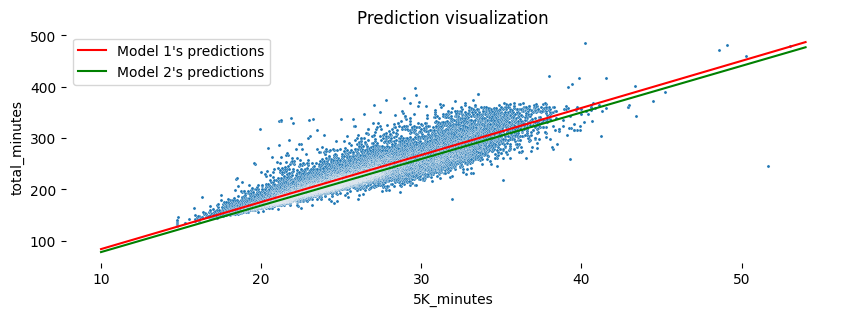

In [12]:
import seaborn as sns
from sklearn.linear_model import LinearRegression

#Model to predict total minutes taken based on minutes taken to reach 5K
model_1=LinearRegression().fit(marathon_results[['5K_minutes']],marathon_results['total_minutes'])

#Model to predict total minutes taken based on age and minutes taken to reach 5K
model_2=LinearRegression().fit(marathon_results[['5K_minutes','Age']],marathon_results['total_minutes'])
plt.figure(figsize=(10, 3))
plt.title('Prediction visualization')
sns.scatterplot(data=marathon_results, x='5K_minutes', y='total_minutes',s=5)
x = np.arange(10, 55)
plt.plot(x, model_1.coef_[0]*x + model_1.intercept_, c='r',label='Model 1\'s predictions')
plt.plot(x, model_2.coef_[0]*x + model_2.intercept_, c='g',label='Model 2\'s predictions')
#Remove unecessary edges
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.legend();

Observably, and as expected, the predictions are slightly different. The models will be evaluated by predicting each runner's total minutes taken. The error of each prediction will be computed by finding the difference between the prediction and the true total minute value. Our hypthesis is that the second model will be more accurate, as it also considers the runner's age.

In [13]:
#New column containing LR1's prediction of the runner's total minutes
marathon_results['LR1_prediction']=model_1.predict(marathon_results[['5K_minutes']])

#New column containing the error of the prediction
marathon_results['LR1_error']=np.abs(marathon_results['LR1_prediction']-marathon_results['total_minutes'])

#New column containing LR2'S prediction of the runner's total minutes
marathon_results['LR2_prediction']=model_2.predict(marathon_results[['5K_minutes','Age']])

#New column containing the error of the prediction
marathon_results['LR2_error']=np.abs(marathon_results['LR2_prediction']-marathon_results['total_minutes'])

#Sum the errors and find the difference
error_difference=marathon_results['LR1_error'].sum()-marathon_results['LR2_error'].sum()
print(f'Model 1 had a greater total error than model 2 by {error_difference} minutes.')

Model 1 had a greater total error than model 2 by 1711.604009134404 minutes.


The results indicate that the second model, which made a prediction based off of both the runner's age and 5K time, outperformed the first model considerably. This also supports the results found from adding dimensions to the KDE Bayesian model; that the addition of more attributes increases prediction accuracy.

## Conclusion ##

This report explored the application of kernel density estimation (KDE), Bayesian modeling, and linear regression techniques to predict attributes of marathon runners. Each of the produced prediction models were tested for accuracy thoroughly. The accuracy of the predictions made using KDE and Bayesian modeling was compared to the accuracy of those made using a k-NN classification approach. The k-NN classification model outperformed both Bayesian models, however further analysis showed that a higher-dimensional KDE Bayesian model is likely projected to outperform the k-NN classifier. 

Moreover, we established a framework for using several statistical techniques to make predictions. There is plentiful opportunity for further exploration through the utilization of these methods in countless other domains of interest.

## References ##

[1] DeepAI, "Kernel Density Estimation."
https://deepai.org/machine-learning-glossary-and-terms/kernel-density-estimation

[2] MLM, "Bayes Theorem for Machine Learning."
https://machinelearningmastery.com/bayes-theorem-for-machine-learning/

[3] IBM, "Linear Regression."
https://www.ibm.com/topics/linear-regression

[4] IBM, "k-Nearest-Neighbors."
https://www.ibm.com/topics/knn

[5] Scikit-learn, "Density Estimation."
https://scikit-learn.org/stable/modules/density.html